# Phase 2 : Token analysis for Gender Detection

This notebook implement token analysis to understand which token is more likely used by the LLM to interprete the gender of the author.

## Environnement setup and model loading

In [1]:
import os
import inseq
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import login
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
load_dotenv()

login(token=os.getenv("HUGGING_FACE_TOKEN"))

/home/anosis/scia/nlp2/slm-user-modeling-research/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = inseq.load_model(
    "google/gemma-3-270m", 
    "integrated_gradients"
)

The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


## Integrated Gradient

First, we will use the inseq library and the integrated gradient method to understand which inputs tokens is more likely used by the llm to interprete the gender

In [3]:
dataset = pd.read_csv("dataset.csv")

In [4]:
torch.cuda.empty_cache()
import gc
gc.collect()

token_bias_sums = {}
token_counts = {}

n_samples = len(dataset)

for idx in range(n_samples):
    text = dataset.iloc[idx]['text']
    
    try:
        generated_m = text + " He"
        generated_f = text + " She"
        
        attrib_m = model.attribute(input_texts=text, generated_texts=generated_m)
        attrib_f = model.attribute(input_texts=text, generated_texts=generated_f)
        
        male_attr = attrib_m.sequence_attributions[0].target_attributions
        female_attr = attrib_f.sequence_attributions[0].target_attributions
        
        if male_attr is None or female_attr is None:
            continue
            
        if male_attr.ndim == 3:
            male_sc = torch.norm(male_attr, dim=-1).numpy()
            female_sc = torch.norm(female_attr, dim=-1).numpy()
        else:
            male_sc = male_attr.numpy()
            female_sc = female_attr.numpy()
        
        male_last = male_sc[:, -1]
        female_last = female_sc[:, -1]
        bias = female_last - male_last
        
        tokens = [t.token for t in attrib_m.sequence_attributions[0].target]
        
        for token, score in zip(tokens[:-1], bias[:-1]):
            if token in token_bias_sums:
                token_bias_sums[token] += score
                token_counts[token] += 1
            else:
                token_bias_sums[token] = score
                token_counts[token] = 1
        
        del attrib_m, attrib_f, male_attr, female_attr
        torch.cuda.empty_cache()
            
    except Exception as e:
        torch.cuda.empty_cache()
        gc.collect()
        continue

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Attributing with integrated_gradients...:  96%|█████████▋| 26/27 [00:00<?, ?it/s]


In [5]:
token_avg_bias = {token: token_bias_sums[token] / token_counts[token] 
                  for token in token_bias_sums}

sorted_tokens = sorted(token_avg_bias.items(), key=lambda x: x[1])

# Top tokens for male
n_top = min(15, len(sorted_tokens) // 2)
top_male = sorted_tokens[:n_top]
top_female = sorted_tokens[-n_top:][::-1]

print(f"\nTop {n_top} tokens influencing male prediction:")
for token, score in top_male:
    print(f"  '{token}': {score:.4f}")

print(f"\nTop {n_top} tokens influencing female prediction:")
for token, score in top_female:
    print(f"  '{token}': {score:.4f}")


Top 15 tokens influencing male prediction:
  '?': -0.0018
  '.': -0.0009
  '▁always': -0.0006
  '▁So': -0.0006
  's': -0.0005
  '▁I': -0.0003
  '▁Smith': -0.0003
  '6': -0.0003
  '▁Fred': -0.0002
  '▁who': -0.0002
  '▁Dies': -0.0002
  '▁Like': -0.0002
  'local': -0.0002
  '▁happen': -0.0001
  '▁Elliott': -0.0001

Top 15 tokens influencing female prediction:
  '▁Buffy': 0.0018
  '▁next': 0.0008
  '▁like': 0.0006
  '▁People': 0.0003
  '▁this': 0.0003
  '▁In': 0.0003
  '▁love': 0.0003
  '▁to': 0.0003
  '▁Face': 0.0003
  '▁.': 0.0003
  'CNN': 0.0003
  'ots': 0.0002
  'amp': 0.0002
  '▁hate': 0.0002
  '▁me': 0.0002


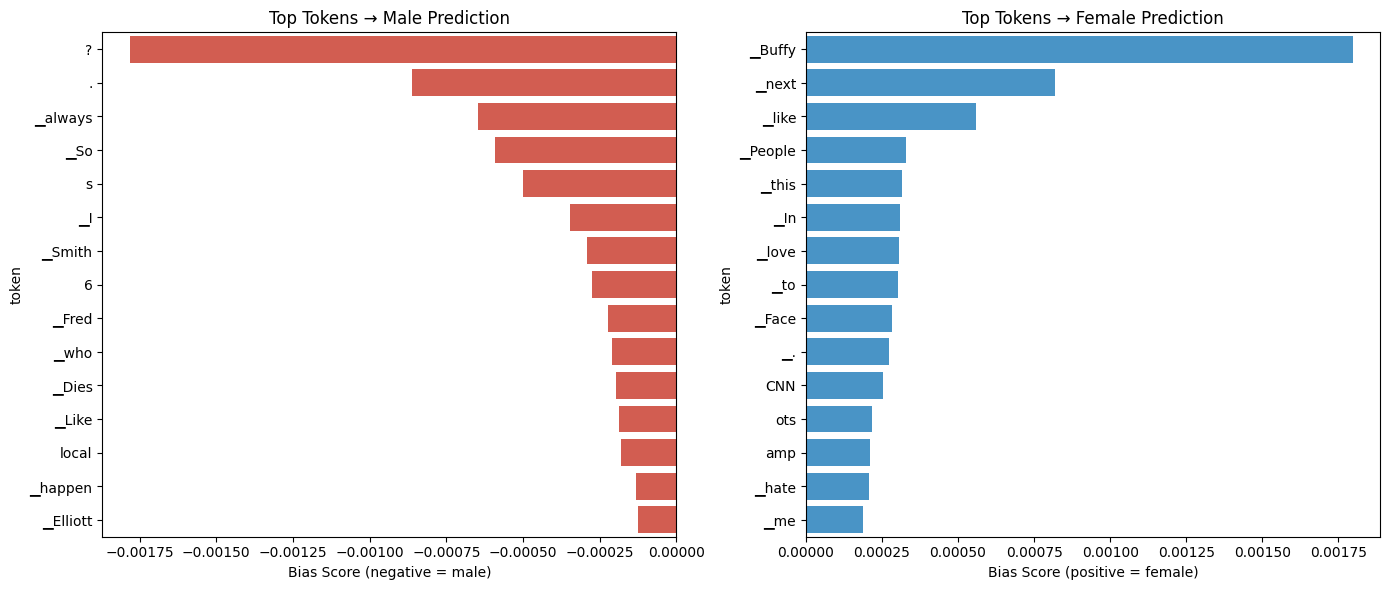

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_male = pd.DataFrame(top_male, columns=['token', 'bias'])
sns.barplot(data=df_male, x='bias', y='token', ax=axes[0], color='#e74c3c')
axes[0].set_title('Top Tokens → Male Prediction')
axes[0].set_xlabel('Bias Score (negative = male)')

df_female = pd.DataFrame(top_female, columns=['token', 'bias'])
sns.barplot(data=df_female, x='bias', y='token', ax=axes[1], color='#3498db')
axes[1].set_title('Top Tokens → Female Prediction')
axes[1].set_xlabel('Bias Score (positive = female)')

plt.tight_layout()
# Reverse the female dataframe order so higher bias scores appear at top
df_female_sorted = df_female.sort_values('bias', ascending=False)
sns.barplot(data=df_female_sorted, x='bias', y='token', ax=axes[1], color='#3498db', order=df_female_sorted['token'])
axes[1].set_title('Top Tokens → Female Prediction')
axes[1].set_xlabel('Bias Score (positive = female)')

plt.tight_layout()
plt.show()

### Results
As we can see, we don't find specific token that the llm will use to interprete the gender of the user writting the prompt. It is quite random, for the male prediction it is "?" which is the more meaningfull token and for the female it is "Buffy"

## Attention Rollout

Now we will use the attention rollout method to understand which input tokens the LLM focuses on when predicting gender. Attention rollout aggregates attention weights across all layers to provide a global view of token importance.

In [7]:
del model
torch.cuda.empty_cache()
gc.collect()

model_rollout = inseq.load_model(
    "google/gemma-3-270m", 
    "attention"
)

In [8]:
torch.cuda.empty_cache()
gc.collect()

token_attention_male = {}
token_attention_female = {}
token_counts_male = {}
token_counts_female = {}

n_samples = len(dataset)
error_count = 0
success_count = 0

for idx in range(n_samples):
    text = dataset.iloc[idx]['text']
    gender = dataset.iloc[idx]['gender'] 
    
    try:
        attrib = model_rollout.attribute(input_texts=text, generated_texts=text + " I")
        
        attr = attrib.sequence_attributions[0].target_attributions
        
        if attr is None:
            continue
        
        if isinstance(attr, torch.Tensor):
            attr = attr.numpy()
        
        while attr.ndim > 1:
            attr = np.mean(attr, axis=-1)
        
        tokens = [t.token for t in attrib.sequence_attributions[0].target]
        
        if gender.lower() in ['male', 'm']:
            token_dict = token_attention_male
            count_dict = token_counts_male
        else:
            token_dict = token_attention_female
            count_dict = token_counts_female
        
        for i, token in enumerate(tokens[:-1]):
            if i < len(attr):
                score = float(attr[i])
                if token in token_dict:
                    token_dict[token] += score
                    count_dict[token] += 1
                else:
                    token_dict[token] = score
                    count_dict[token] = 1
        
        success_count += 1
        del attrib, attr
        torch.cuda.empty_cache()
            
    except Exception as e:
        error_count += 1
        if error_count <= 3:
            print(f"Error at sample {idx}: {type(e).__name__}: {e}")
        torch.cuda.empty_cache()
        gc.collect()
        continue

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Attributing with attention...: 35it [00:00, 18.12it/s]
Attributing with attention...: 30it [00:00, 19.46it/s]
Attributing with attention...: 628it [00:00,  2.61it/s]
Attributing with attention...: 7it [00:00, 22.96it/s]
Attributing with attention...: 155it [00:00, 15.08it/s]
Attributing with attention...: 175it [00:00, 14.00it/s]
Attributing with attention...: 360it [00:00,  5.95it/s]
Attributing with attention...: 635it [00:00,  2.64it/s]
Attributing with attention...: 261it [00:00,  7.70it/s]
Attributing with attention...: 226it [00:00, 10.94it/s]
Attributing with attention...: 194it [00:00, 12.51it/s]
Attributing with attention...: 490it [00:00,  4.49it/s]
Attributing with attention...: 150it [00:00, 15.71it/s]
Attributing with attention...: 102it [00:00, 16.89it/s]
Attributing with attention...: 287it [00:00,  7.16it/s]
Attributing with attent

In [9]:
avg_attention_male = {token: token_attention_male[token] / token_counts_male[token] 
                      for token in token_attention_male}
avg_attention_female = {token: token_attention_female[token] / token_counts_female[token] 
                        for token in token_attention_female}

common_tokens = set(avg_attention_male.keys()) & set(avg_attention_female.keys())
token_gender_diff = {token: avg_attention_female[token] - avg_attention_male[token] 
                     for token in common_tokens}

sorted_tokens_rollout = sorted(token_gender_diff.items(), key=lambda x: x[1])

n_top = min(15, len(sorted_tokens_rollout) // 2)
top_male_rollout = sorted_tokens_rollout[:n_top]
top_female_rollout = sorted_tokens_rollout[-n_top:][::-1]

print(f"\nTop {n_top} tokens with higher attention in male-authored texts:")
for token, score in top_male_rollout:
    print(f"  '{token}': {score:.6f}")

print(f"\nTop {n_top} tokens with higher attention in female-authored texts:")
for token, score in top_female_rollout:
    print(f"  '{token}': {score:.6f}")


Top 15 tokens with higher attention in male-authored texts:
  '▁Russell': -0.019729
  '▁tense': nan
  '▁rick': -0.044048
  '▁youngest': -0.000157
  '▁Try': 0.003183
  'ison': 0.007825
  '▁paycheck': nan
  '▁photos': nan
  'tch': nan
  '▁Horror': nan
  '▁every': nan
  '▁ng': nan
  '▁Lambert': -0.112968
  '▁▁▁▁▁▁▁▁▁▁▁': -0.038326
  'rained': -0.024158

Top 15 tokens with higher attention in female-authored texts:
  'HEY': nan
  '▁weren': nan
  'another': 0.013822
  'endum': 0.006182
  '▁Brett': 0.001964
  '▁hindi': 0.000970
  '▁moon': nan
  '▁wrongly': -0.000492
  'log': nan
  '▁boy': nan
  'ry': nan
  '▁tips': nan
  '▁doing': nan
  '▁listen': nan
  '▁Trevor': 0.028268


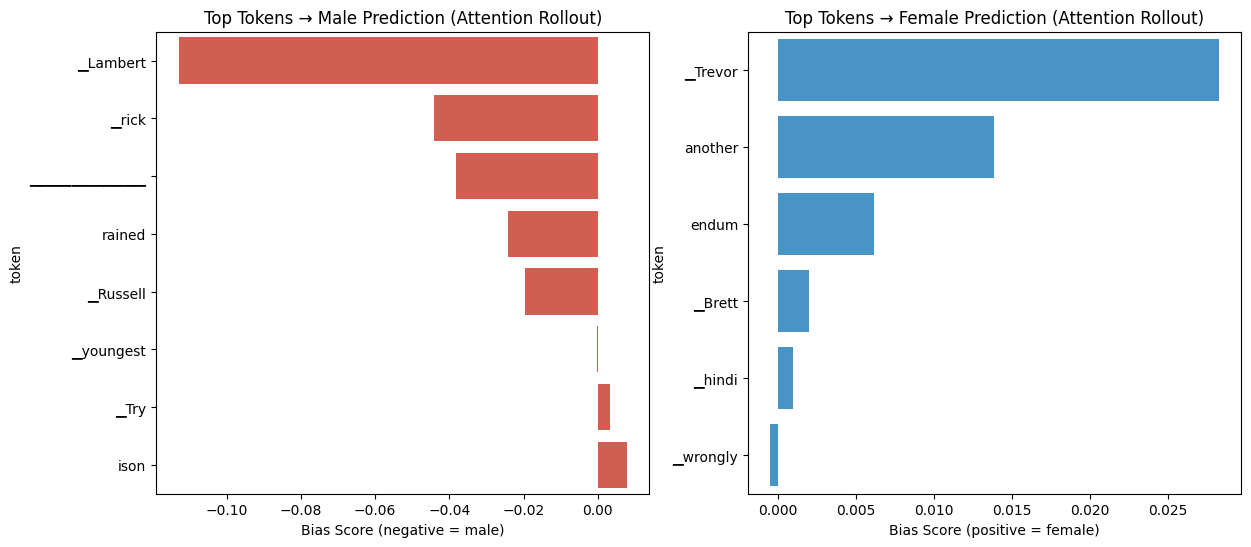

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_male_rollout = pd.DataFrame(top_male_rollout, columns=['token', 'bias'])
df_female_rollout = pd.DataFrame(top_female_rollout, columns=['token', 'bias'])

df_male_rollout_sorted = df_male_rollout.dropna().sort_values('bias', ascending=True)
df_female_rollout_sorted = df_female_rollout.dropna().sort_values('bias', ascending=False)

axes[0].clear()
axes[1].clear()

sns.barplot(data=df_male_rollout_sorted, x='bias', y='token', ax=axes[0], color='#e74c3c', order=df_male_rollout_sorted['token'])
axes[0].set_title('Top Tokens → Male Prediction (Attention Rollout)')
axes[0].set_xlabel('Bias Score (negative = male)')

sns.barplot(data=df_female_rollout_sorted, x='bias', y='token', ax=axes[1], color='#3498db', order=df_female_rollout_sorted['token'])
axes[1].set_title('Top Tokens → Female Prediction (Attention Rollout)')
axes[1].set_xlabel('Bias Score (positive = female)')
plt.show()

### Results
Similar to the integrated gradients method, attention rollout analysis reveals that their is no specific token revealing the gender of the user 